In [4]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['font.size'] = 12

x0, y0 = 0, 0.5
x_end, h = 3.0, 0.2


In [5]:
def exact_solution(x):
    return (x+1)**2 - 0.5*np.exp(x)

def f(x, y):
    return y - x**2 + 1

def runge_kutta_4_step(x, y, h):
    k1 = f(x, y)
    k2 = f(x + h/2, y + h/2 * k1)
    k3 = f(x + h/2, y + h/2 * k2)
    k4 = f(x + h, y + h * k3)
    return y + h/6 * (k1 + 2*k2 + 2*k3 + k4)

def adams_bashforth_2(f, x0, y0, x_end, h):
    x = np.arange(x0, x_end + h, h)
    y = np.zeros(len(x))
    y[0] = y0
    
    # Первый шаг делаем точным классическим методом (РК4)
    y[1] = runge_kutta_4_step(x[0], y[0], h)
    
    # Далее используем явный 2-шаговый метод Адамса-Башфорта
    for i in range(1, len(x)-1):
        y[i+1] = y[i] + h/2 * (3*f(x[i], y[i]) - f(x[i-1], y[i-1]))
    return x, y


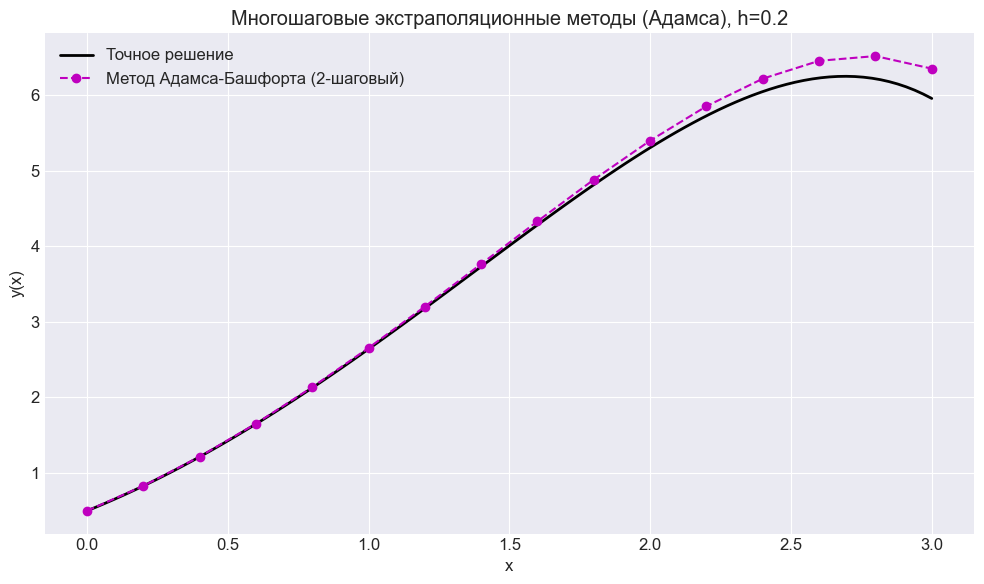

In [6]:
x_exact = np.linspace(x0, x_end, 100)
y_exact = exact_solution(x_exact)
x_ab, y_ab = adams_bashforth_2(f, x0, y0, x_end, h)

plt.figure(figsize=(10, 6))
plt.plot(x_exact, y_exact, 'k-', linewidth=2, label='Точное решение')
plt.plot(x_ab, y_ab, 'mo--', label='Метод Адамса-Башфорта (2-шаговый)')
plt.title(f'Многошаговые экстраполяционные методы (Адамса), h={h}')
plt.xlabel('x')
plt.ylabel('y(x)')
plt.legend()
plt.tight_layout()
plt.show()
